# Baseline models

In [17]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [3]:
df.head()

,casos,week_canton,rr,clasi_rr,urb,tmin_min,tmin_max,tmin_mean,tmin_median,tmax_min,...,precip_median_lag_2,precip_median_lag_1,precip_min_lag_8,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1
0,4,2020-9-101,0.459451,Medio,1,16.785858,20.006693,18.775265,19.645410,26.733393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,2,2020-10-101,0.224397,Medio,1,17.235245,19.964815,18.723231,18.793407,26.638765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,2,2020-11-101,0.253939,Medio,1,18.474545,19.621017,19.110772,19.157510,27.162430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0,2020-12-101,0.000000,Bajo,1,18.497475,19.358017,18.967383,19.099348,26.924604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.377879,0.0,0.0
4,0,2020-13-101,0.000000,Bajo,1,17.836336,19.390366,18.653528,18.680185,27.018480,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [4]:
# CHANGE THIS WHEN THE DATA IS OK, THIS IS BASICALLY A SIN TO GET THE MODEL TO WORK
df.drop(columns=['casos'], inplace=True)
df.drop(columns = ["rr"], inplace = True)
df.dropna(inplace=True)

In [5]:
df.drop(columns = ["rr_lag_1"], inplace = True)
df.drop(columns = ["casos_lag_1"], inplace = True)
df.drop(columns = ["rr_lag_2"], inplace = True)
df.drop(columns = ["casos_lag_2"], inplace = True)
df.drop(columns = ["rr_lag_3"], inplace = True)
df.drop(columns = ["casos_lag_3"], inplace = True)
df.drop(columns = ["rr_lag_4"], inplace = True)
df.drop(columns = ["casos_lag_4"], inplace = True)
df.drop(columns = ["rr_lag_5"], inplace = True)
df.drop(columns = ["casos_lag_5"], inplace = True)
df.drop(columns = ["rr_lag_6"], inplace = True)
df.drop(columns = ["casos_lag_6"], inplace = True)
df.drop(columns = ["rr_lag_7"], inplace = True)
df.drop(columns = ["casos_lag_7"], inplace = True)
df.drop(columns = ["rr_lag_8"], inplace = True)
df.drop(columns = ["casos_lag_8"], inplace = True)

In [6]:
df.shape

(20817, 148)

In [7]:
df = pd.get_dummies(df, columns = ["urb"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_1"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_2"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_3"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_4"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_5"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_6"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_7"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_8"])

In [8]:
df.head()

,week_canton,clasi_rr,tmin_min,tmin_max,tmin_mean,tmin_median,tmax_min,tmax_max,tmax_mean,tmax_median,...,clasi_rr_lag_5_Medio,clasi_rr_lag_6_Alto,clasi_rr_lag_6_Bajo,clasi_rr_lag_6_Medio,clasi_rr_lag_7_Alto,clasi_rr_lag_7_Bajo,clasi_rr_lag_7_Medio,clasi_rr_lag_8_Alto,clasi_rr_lag_8_Bajo,clasi_rr_lag_8_Medio
0,2020-9-101,Medio,16.785858,20.006693,18.775265,19.645410,26.733393,28.077051,27.372263,27.085123,...,False,True,False,False,True,False,False,False,False,True
1,2020-10-101,Medio,17.235245,19.964815,18.723231,18.793407,26.638765,28.377457,27.568323,27.866480,...,False,True,False,False,True,False,False,True,False,False
2,2020-11-101,Medio,18.474545,19.621017,19.110772,19.157510,27.162430,27.981869,27.610641,27.503464,...,True,False,True,False,True,False,False,True,False,False
3,2020-12-101,Bajo,18.497475,19.358017,18.967383,19.099348,26.924604,27.665537,27.361927,27.434515,...,False,False,False,True,False,True,False,True,False,False
4,2020-13-101,Bajo,17.836336,19.390366,18.653528,18.680185,27.018480,28.346085,27.606657,27.502207,...,True,True,False,False,False,False,True,False,True,False


In [10]:
train = df[df['week_canton'] < '2024-1-101']
val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
test = df[df['week_canton'] >= '2025-1-101']

X_train = train.drop(columns = ["clasi_rr", "week_canton"])
y_train = train["clasi_rr"]

X_val = val.drop(columns = ["clasi_rr", "week_canton"])
y_val= val["clasi_rr"]

X_test= test.drop(columns = ["clasi_rr", "week_canton"])
y_test = test["clasi_rr"]

In [11]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [12]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [13]:
train.shape, val.shape, test.shape

((14013, 166), (3726, 166), (3078, 166))

## Logistic regression

In [14]:
reg = LogisticRegression()

reg.fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
print(classification_report(y_test_for_reg, y_pred_reg))

              precision    recall  f1-score   support

        Alto       0.71      0.70      0.71      2509
        Bajo       0.75      0.79      0.77      3305
       Medio       0.55      0.47      0.51       990

    accuracy                           0.71      6804
   macro avg       0.67      0.65      0.66      6804
weighted avg       0.71      0.71      0.71      6804



In [19]:
cnf_matrix_reg = confusion_matrix(y_test_for_reg, y_pred_reg)
cnf_matrix_reg

array([[1765,  595,  149],
       [ 478, 2597,  230],
       [ 250,  274,  466]])

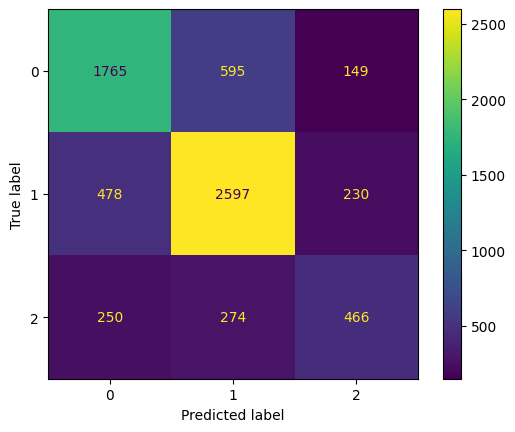

In [20]:
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_reg).plot()

In [27]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_[0]})
sd = pd.DataFrame({"Feature": X_train.columns, "Std": X_train_scaled.std()})
coef_df = coef_df.merge(sd, on = "Feature")
coef_df["Coefficient_std"] = coef_df["Coefficient"] * coef_df["Std"]
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=False)

coef_reg_sorted

,Feature,Coefficient,Std,Coefficient_std
46,tmax_median_lag_3,0.375777,1.000036,0.375791
58,tmin_max_lag_7,0.312044,1.000036,0.312056
55,tmax_min_lag_2,0.242764,1.000036,0.242772
50,tmax_min_lag_7,0.233630,1.000036,0.233638
45,tmax_median_lag_4,0.221598,1.000036,0.221606
...,...,...,...,...
85,tmin_min_lag_4,-0.318544,1.000036,-0.318555
0,tmin_min,-0.325212,1.000036,-0.325224
54,tmax_min_lag_3,-0.378025,1.000036,-0.378038
76,tmin_median_lag_5,-0.401343,1.000036,-0.401357


Text(0.5, 0, 'Coefficient')

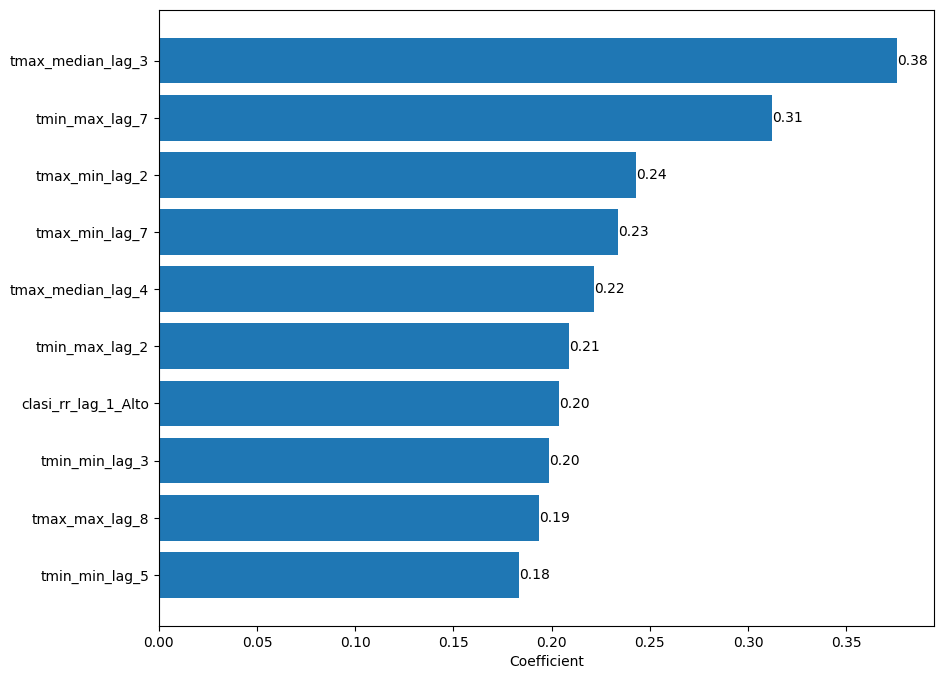

In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=True)
ax.barh(coef_reg_sorted["Feature"].tail(10), coef_reg_sorted["Coefficient_std"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [21]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test_for_reg_scaled)

In [22]:
print(classification_report(y_test_for_reg, y_pred_rf))

              precision    recall  f1-score   support

        Alto       0.13      0.05      0.07      2509
        Bajo       0.43      0.76      0.55      3305
       Medio       0.55      0.05      0.10       990

    accuracy                           0.39      6804
   macro avg       0.37      0.29      0.24      6804
weighted avg       0.34      0.39      0.31      6804



In [23]:
cnf_matrix_rf = confusion_matrix(y_test_for_reg, y_pred_rf)
cnf_matrix_rf

array([[ 114, 2375,   20],
       [ 777, 2506,   22],
       [  20,  918,   52]])

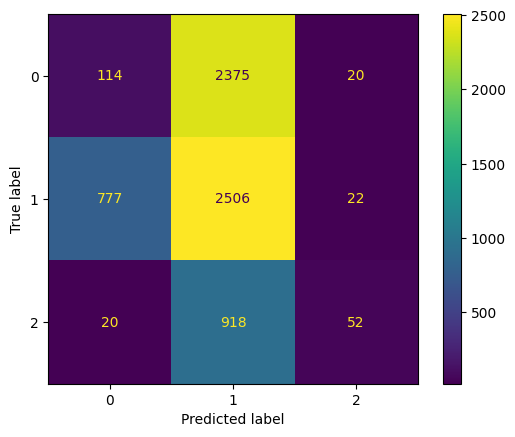

In [29]:
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_rf).plot()

In [34]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
141,clasi_rr_lag_1_Bajo,0.045291
140,clasi_rr_lag_1_Alto,0.041176
144,clasi_rr_lag_2_Bajo,0.038522
147,clasi_rr_lag_3_Bajo,0.034795
143,clasi_rr_lag_2_Alto,0.034429
...,...,...
131,precip_min_lag_6,0.001170
129,precip_min_lag_8,0.001098
9,precip_min,0.001020
137,urb_0,0.000750


Text(0.5, 0, 'Importance')

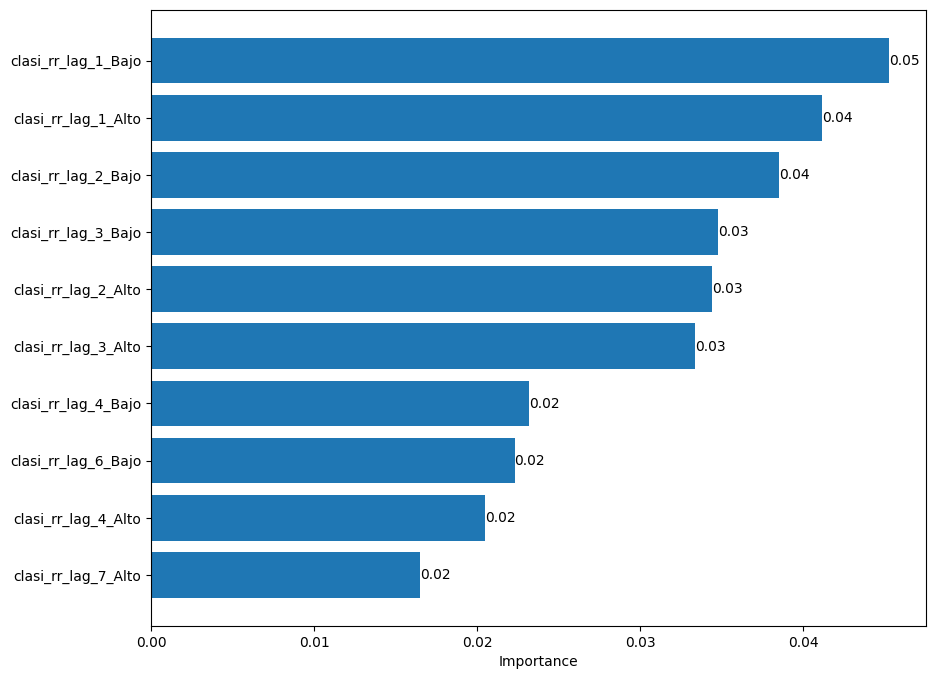

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"].tail(10), imp_rf_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")